# GVH Diagonal Cubic — RACC-C.4-real.1
## GW150914 H1/L1 — Timing Certification

**Auteur :** Charlemagne O Laurince  
**Étape :** `RACC-C.4-real.1`  
**Statut :** certification observationnelle du timing H1/L1  
**Noyau GVH Diagonal modifié :** **NON**

Objectif : résoudre l'ambiguïté de timing observée dans `RACC-C.4-real` sans utiliser une valeur publiée pour sélectionner la branche.

Estimateurs :
1. corrélation temporelle directe ;
2. polarité \(L1\to\pm L1\) séparée du signe du retard ;
3. GCC-PHAT ;
4. pente de phase inter-détecteurs ;
5. grille de fenêtres ;
6. bootstrap avec bruit hors événement ;
7. interpolation sous-échantillon.

\[
\boxed{D_T^{\rm ref}=\texttt{NOT\_AUTHORIZED}}
\]
tant que `TIMING_VALIDATED != True`.


## 0. Données attendues

```text
gvh_diagonal_cubic/data/GW150914/
├── H-H1_LOSC_4_V2-1126259446-32.gwf
└── L-L1_LOSC_4_V2-1126259446-32.gwf
```

Les variantes de nom comme `...-32 2.gwf` sont acceptées.


In [1]:

import os, sys, subprocess, importlib, hashlib, json
from pathlib import Path

def pip_install(pkg):
    print(f"Installation de {pkg} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import lalframe
except Exception:
    pip_install("lalsuite")
    importlib.invalidate_caches()
    import lalframe

try:
    import gwpy
except Exception:
    pip_install("gwpy")
    importlib.invalidate_caches()
    import gwpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from gwpy.timeseries import TimeSeries

print("gwpy:", gwpy.__version__)
print("LALFrame available: True")


Installation de lalsuite ...


/usr/local/lib/python3.12/dist-packages/lalframe/_lalframe_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Installation de gwpy ...
gwpy: 4.0.1
LALFrame available: True


In [2]:

try:
    import lal
    import lalframe
    LALFRAME_AVAILABLE = True
except Exception as exc:
    LALFRAME_AVAILABLE = False
    LALFRAME_ERROR = repr(exc)

print("LALFRAME_AVAILABLE =", LALFRAME_AVAILABLE)
if not LALFRAME_AVAILABLE:
    raise RuntimeError("LALFrame indisponible. Installer lalsuite puis relancer.")


LALFRAME_AVAILABLE = True


## 1. Configuration et découverte des fichiers

In [3]:

GPS_EVENT = 1126259462.0
FS_EXPECTED = 4096.0
DURATION_S = 32
N_EXPECTED = int(FS_EXPECTED * DURATION_S)

H1_CHANNEL = "H1:LOSC-STRAIN"
L1_CHANNEL = "L1:LOSC-STRAIN"
H1_PATTERN = "H-H1_LOSC_4_V2-1126259446-32*.gwf"
L1_PATTERN = "L-L1_LOSC_4_V2-1126259446-32*.gwf"

def discover_one(pattern):
    roots=[Path.cwd(),Path("/content"),Path("/content/drive/MyDrive"),Path("/mnt/data")]
    out=[]; seen=set()
    for root in roots:
        if not root.exists(): continue
        for d in [root,root/"data"/"GW150914",root/"gvh_diagonal_cubic"/"data"/"GW150914"]:
            if d.exists():
                for p in d.glob(pattern):
                    rp=p.resolve()
                    if rp not in seen: seen.add(rp); out.append(rp)
        try:
            for p in root.glob(f"**/GW150914/{pattern}"):
                rp=p.resolve()
                if rp not in seen: seen.add(rp); out.append(rp)
        except Exception:
            pass
    return out[0] if out else None

H1_FILE=discover_one(H1_PATTERN)
L1_FILE=discover_one(L1_PATTERN)

if H1_FILE is None or L1_FILE is None:
    try:
        from google.colab import files as colab_files
        print("Sélectionnez H1 et L1.")
        colab_files.upload()
        H1_FILE=discover_one(H1_PATTERN)
        L1_FILE=discover_one(L1_PATTERN)
    except Exception:
        pass

print("H1_FILE:",H1_FILE)
print("L1_FILE:",L1_FILE)
if H1_FILE is None or L1_FILE is None:
    raise FileNotFoundError("Fichiers H1/L1 non trouvés.")


Sélectionnez H1 et L1.


Saving H-H1_LOSC_4_V2-1126259446-32 2.gwf to H-H1_LOSC_4_V2-1126259446-32 2.gwf
Saving L-L1_LOSC_4_V2-1126259446-32.gwf to L-L1_LOSC_4_V2-1126259446-32.gwf
H1_FILE: /content/H-H1_LOSC_4_V2-1126259446-32 2.gwf
L1_FILE: /content/L-L1_LOSC_4_V2-1126259446-32.gwf


## 2. Chargement et gate d'intégrité

In [4]:

def md5sum(path, chunk=1024*1024):
    h=hashlib.md5()
    with open(path,"rb") as f:
        while True:
            b=f.read(chunk)
            if not b: break
            h.update(b)
    return h.hexdigest()

h1_ts=TimeSeries.read(str(H1_FILE),channel=H1_CHANNEL)
l1_ts=TimeSeries.read(str(L1_FILE),channel=L1_CHANNEL)
h1=np.asarray(h1_ts.value,float)
l1=np.asarray(l1_ts.value,float)

fs_h1=float(h1_ts.sample_rate.value)
fs_l1=float(l1_ts.sample_rate.value)
gps_h1=float(h1_ts.t0.value)
gps_l1=float(l1_ts.t0.value)

integrity=pd.DataFrame([
    {"detector":"H1","N":len(h1),"fs_hz":fs_h1,"gps_start":gps_h1,"md5":md5sum(H1_FILE),"finite":bool(np.isfinite(h1).all())},
    {"detector":"L1","N":len(l1),"fs_hz":fs_l1,"gps_start":gps_l1,"md5":md5sum(L1_FILE),"finite":bool(np.isfinite(l1).all())},
])
display(integrity)

REAL_DATA_INTEGRITY=bool(
    len(h1)==N_EXPECTED and len(l1)==N_EXPECTED
    and np.isclose(fs_h1,FS_EXPECTED) and np.isclose(fs_l1,FS_EXPECTED)
    and np.isclose(gps_h1,gps_l1)
    and np.isfinite(h1).all() and np.isfinite(l1).all()
)
print("REAL_DATA_INTEGRITY =",REAL_DATA_INTEGRITY)
assert REAL_DATA_INTEGRITY


,detector,N,fs_hz,gps_start,md5,finite
0,H1,131072,4096.0,1.126259e+09,c48f3983e9e6ee882daedc2bf328072a,True
1,L1,131072,4096.0,1.126259e+09,705824bc5b3359f27ba4db80c7881be7,True


REAL_DATA_INTEGRITY = True


## 3. Prétraitement

In [5]:

fs=fs_h1
gps=gps_h1+np.arange(len(h1))/fs
t_rel=gps-GPS_EVENT
NOISE_MASK=((t_rel>=-12)&(t_rel<=-2))|((t_rel>=2)&(t_rel<=12))

def bandpass_notch(x,fs,lo=35.,hi=350.):
    x=np.asarray(x,float)-np.mean(x)
    sos=signal.butter(4,[lo,hi],btype="bandpass",fs=fs,output="sos")
    y=signal.sosfiltfilt(sos,x)
    for f0 in [60.,120.,180.,240.,300.]:
        if f0<hi:
            b,a=signal.iirnotch(f0,Q=30.,fs=fs)
            y=signal.filtfilt(b,a,y)
    return y

def robust_normalize(x):
    xn=x[NOISE_MASK]
    med=np.median(xn)
    mad=np.median(np.abs(xn-med))
    sig=1.4826*mad
    return (x-med)/sig,med,sig

h1_z,h1_med,h1_sigma=robust_normalize(bandpass_notch(h1,fs))
l1_z,l1_med,l1_sigma=robust_normalize(bandpass_notch(l1,fs))
PREPROCESSING_FINITE=bool(np.isfinite(h1_z).all() and np.isfinite(l1_z).all() and h1_sigma>0 and l1_sigma>0)
print("PREPROCESSING_FINITE =",PREPROCESSING_FINITE)
assert PREPROCESSING_FINITE


PREPROCESSING_FINITE = True


## 4. Outils communs

In [6]:

MAX_LAG_S=0.012

def parabolic_subsample(a,b,c):
    den=a-2*b+c
    return 0.0 if den==0 or not np.isfinite(den) else 0.5*(a-c)/den

def xcorr_lag(x,y,fs,max_lag_s=MAX_LAG_S,use_abs=True):
    x=np.asarray(x,float)-np.mean(x); y=np.asarray(y,float)-np.mean(y)
    c=signal.correlate(x,y,mode="full",method="fft")
    lags=signal.correlation_lags(len(x),len(y),mode="full")/fs
    keep=np.abs(lags)<=max_lag_s
    c=c[keep]; lags=lags[keep]
    cn=c/(np.linalg.norm(x)*np.linalg.norm(y))
    score=np.abs(cn) if use_abs else cn
    ib=int(np.argmax(score))
    frac=parabolic_subsample(score[ib-1],score[ib],score[ib+1]) if 0<ib<len(score)-1 else 0.0
    lag_sub=float(lags[ib]+frac/fs)
    corr=float(cn[ib])

    order=np.argsort(score)[::-1]; used=[]; peaks=[]; min_sep=max(1,int(round(.0015*fs)))
    for idx in order:
        if all(abs(idx-u)>=min_sep for u in used):
            used.append(idx)
            peaks.append({"lag_ms":float(lags[idx]*1e3),"corr":float(cn[idx]),"abs_corr":float(abs(cn[idx]))})
        if len(peaks)>=5: break
    return lag_sub,corr,pd.DataFrame(peaks),lags,cn


## 5. Corrélation directe et polarité

In [7]:

TIMING_WINDOW=(-0.12,0.04)
m=(t_rel>=TIMING_WINDOW[0])&(t_rel<=TIMING_WINDOW[1])
xh=h1_z[m]; xl=l1_z[m]

lag_plus,corr_plus,_,_,_=xcorr_lag(xh,xl,fs,use_abs=False)
lag_minus,corr_minus,_,_,_=xcorr_lag(xh,-xl,fs,use_abs=False)
lag_abs,corr_abs,peaks_abs,lags_abs,cn_abs=xcorr_lag(xh,xl,fs,use_abs=True)

display(pd.DataFrame([
    {"mode":"H1 vs +L1","lag_ms":lag_plus*1e3,"corr":corr_plus},
    {"mode":"H1 vs -L1","lag_ms":lag_minus*1e3,"corr":corr_minus},
    {"mode":"max |corr|","lag_ms":lag_abs*1e3,"corr":corr_abs},
]))
display(peaks_abs)


,mode,lag_ms,corr
0,H1 vs +L1,-7.415881,0.488011
1,H1 vs -L1,6.138360,0.490109
2,max |corr|,6.138360,-0.490109


,lag_ms,corr,abs_corr
0,6.103516,-0.490109,0.490109
1,-7.324219,0.488011,0.488011
2,8.789062,-0.452753,0.452753
3,-4.882812,0.433958,0.433958
4,-8.789062,0.375362,0.375362


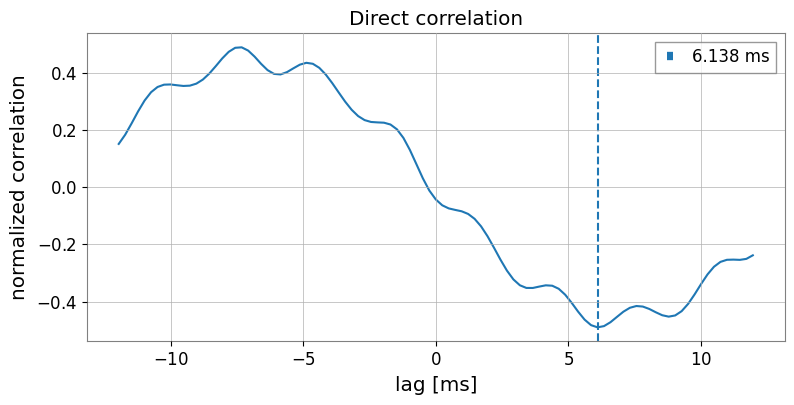

In [8]:

plt.figure(figsize=(9,4))
plt.plot(lags_abs*1e3,cn_abs)
plt.axvline(lag_abs*1e3,linestyle="--",label=f"{lag_abs*1e3:.3f} ms")
plt.xlabel("lag [ms]"); plt.ylabel("normalized correlation")
plt.title("Direct correlation"); plt.grid(True); plt.legend(); plt.show()


## 6. GCC-PHAT

In [9]:

def gcc_phat_lag(x,y,fs,max_lag_s=MAX_LAG_S):
    x=np.asarray(x,float)-np.mean(x); y=np.asarray(y,float)-np.mean(y)
    n=int(2**np.ceil(np.log2(len(x)+len(y))))
    X=np.fft.rfft(x,n=n); Y=np.fft.rfft(y,n=n)
    G=X*np.conj(Y); R=G/(np.abs(G)+np.finfo(float).eps)
    cc=np.fft.irfft(R,n=n)
    cc=np.concatenate((cc[-n//2:],cc[:n//2]))
    lags=np.arange(-n//2,n//2)/fs
    keep=np.abs(lags)<=max_lag_s
    cc=cc[keep]; lags=lags[keep]
    score=np.abs(cc); ib=int(np.argmax(score))
    frac=parabolic_subsample(score[ib-1],score[ib],score[ib+1]) if 0<ib<len(score)-1 else 0.0
    return float(lags[ib]+frac/fs),float(cc[ib]),lags,cc

lag_phat,cc_phat,lags_phat,curve_phat=gcc_phat_lag(xh,xl,fs)
print("GCC-PHAT lag [ms] =",lag_phat*1e3)


GCC-PHAT lag [ms] = -0.043222285962960384


## 7. Pente de phase

In [10]:

def phase_slope_lag(x,y,fs,fmin=40.,fmax=300.):
    nperseg=min(1024,len(x))
    f,Pxy=signal.csd(x,y,fs=fs,nperseg=nperseg,noverlap=nperseg//2,window="hann")
    _,coh=signal.coherence(x,y,fs=fs,nperseg=nperseg,noverlap=nperseg//2,window="hann")
    phase=np.unwrap(np.angle(Pxy))
    mask=(f>=fmin)&(f<=fmax)&np.isfinite(phase)&np.isfinite(coh)&(coh>=0.10)
    ff=f[mask]; pp=phase[mask]; ww=coh[mask]
    if len(ff)<5: return np.nan,np.nan,f,phase,coh,mask
    A=np.column_stack([ff,np.ones_like(ff)]); W=np.sqrt(ww)[:,None]
    beta,*_=np.linalg.lstsq(A*W,pp*np.sqrt(ww),rcond=None)
    slope,intercept=beta
    lag=-slope/(2*np.pi)
    pred=slope*ff+intercept
    ss_res=np.sum(ww*(pp-pred)**2); ss_tot=np.sum(ww*(pp-np.average(pp,weights=ww))**2)
    r2=1-ss_res/ss_tot if ss_tot>0 else np.nan
    return float(lag),float(r2),f,phase,coh,mask

lag_phase,phase_r2,_,_,_,_=phase_slope_lag(xh,xl,fs)
print("phase-slope lag [ms] =",lag_phase*1e3)
print("phase R2 =",phase_r2)


phase-slope lag [ms] = 2.0750347912664817
phase R2 = 0.10786560913115228


## 8. Grille de fenêtres

In [11]:

rows=[]
for t0 in np.arange(-0.16,-0.079,0.01):
    for t1 in np.arange(0.00,0.061,0.01):
        if t1-t0<0.08: continue
        mm=(t_rel>=t0)&(t_rel<=t1)
        if mm.sum()<200: continue
        lx,cx,_,_,_=xcorr_lag(h1_z[mm],l1_z[mm],fs,use_abs=True)
        lp,cp,_,_=gcc_phat_lag(h1_z[mm],l1_z[mm],fs)
        rows.append({"t0":float(t0),"t1":float(t1),"xcorr_lag_ms":lx*1e3,"xcorr_abs_corr":abs(cx),"phat_lag_ms":lp*1e3,"phat_abs_peak":abs(cp)})
window_df=pd.DataFrame(rows)
display(window_df.head())
print("window count =",len(window_df))


,t0,t1,xcorr_lag_ms,xcorr_abs_corr,phat_lag_ms,phat_abs_peak
0,-0.16,0.00,9.113379,0.514964,-0.035119,0.462850
1,-0.16,0.01,9.077743,0.514293,9.799050,0.131433
2,-0.16,0.02,9.020023,0.503737,-1.042572,0.097716
3,-0.16,0.03,9.017005,0.506294,-0.032274,0.569988
4,-0.16,0.04,9.002982,0.491116,-0.033298,0.589265


window count = 62


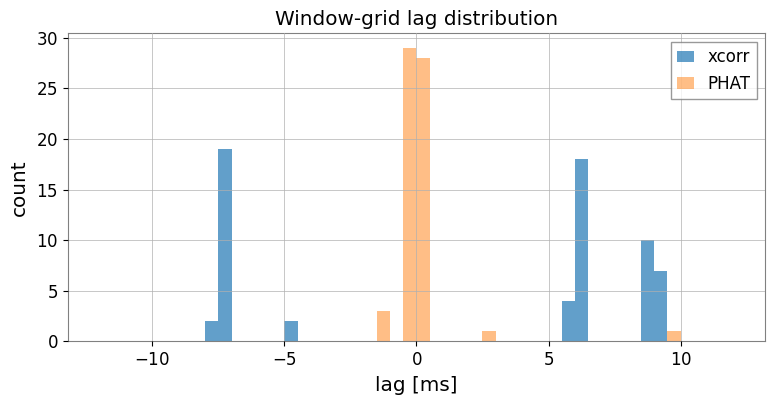

In [12]:

plt.figure(figsize=(9,4))
bins=np.arange(-12,12.5,.5)
plt.hist(window_df["xcorr_lag_ms"],bins=bins,alpha=.7,label="xcorr")
plt.hist(window_df["phat_lag_ms"],bins=bins,alpha=.5,label="PHAT")
plt.xlabel("lag [ms]"); plt.ylabel("count"); plt.title("Window-grid lag distribution")
plt.grid(True); plt.legend(); plt.show()


## 9. Branches

In [13]:

def branch_stats(values_ms,split_ms=1.0):
    v=np.asarray(values_ms,float); total=len(v)
    groups=[("positive",v[v>split_ms]),("negative",v[v<-split_ms]),("near_zero",v[np.abs(v)<=split_ms])]
    return pd.DataFrame([{
        "branch":name,"count":len(a),"fraction":len(a)/total if total else np.nan,
        "median_ms":float(np.median(a)) if len(a) else np.nan,
        "mad_ms":float(np.median(np.abs(a-np.median(a)))) if len(a) else np.nan
    } for name,a in groups])

display(branch_stats(window_df["xcorr_lag_ms"]))
display(branch_stats(window_df["phat_lag_ms"]))


,branch,count,fraction,median_ms,mad_ms
0,positive,39,0.629032,6.214452,0.246198
1,negative,23,0.370968,-7.424815,0.067323
2,near_zero,0,0.000000,NaN,NaN


,branch,count,fraction,median_ms,mad_ms
0,positive,2,0.032258,6.197524,3.601526
1,negative,3,0.048387,-1.193315,0.005145
2,near_zero,57,0.919355,-0.004980,0.028319


## 10. Bootstrap avec bruit hors événement

In [14]:

RNG=np.random.default_rng(20260811)
nwin=len(xh)
starts=np.where(NOISE_MASK)[0]
starts=starts[starts<=len(h1_z)-nwin-1]

def bootstrap_lags(n_boot=300,noise_fraction=.35):
    rows=[]
    for b in range(n_boot):
        s=int(RNG.choice(starts))
        nh=h1_z[s:s+nwin]; nl=l1_z[s:s+nwin]
        xb=xh+noise_fraction*(nh-np.mean(nh))
        yb=xl+noise_fraction*(nl-np.mean(nl))
        lx,cx,_,_,_=xcorr_lag(xb,yb,fs,use_abs=True)
        lp,cp,_,_=gcc_phat_lag(xb,yb,fs)
        rows.append({"boot":b,"xcorr_lag_ms":lx*1e3,"xcorr_abs_corr":abs(cx),"phat_lag_ms":lp*1e3,"phat_abs_peak":abs(cp)})
    return pd.DataFrame(rows)

boot_df=bootstrap_lags()
display(branch_stats(boot_df["xcorr_lag_ms"]))
display(branch_stats(boot_df["phat_lag_ms"]))


,branch,count,fraction,median_ms,mad_ms
0,positive,199,0.663333,6.096439,0.346285
1,negative,95,0.316667,-4.837304,2.542626
2,near_zero,6,0.020000,0.233694,0.051381


,branch,count,fraction,median_ms,mad_ms
0,positive,0,0.0,NaN,NaN
1,negative,0,0.0,NaN,NaN
2,near_zero,300,1.0,-0.046927,0.027549


## 11. Critères de certification

In [15]:

def dominant_branch(df,col):
    bs=branch_stats(df[col])
    usable=bs[bs["branch"].isin(["positive","negative"])]
    if len(usable)==0: return None,np.nan,np.nan
    row=usable.iloc[int(np.argmax(usable["fraction"].to_numpy()))]
    return row["branch"],float(row["fraction"]),float(row["median_ms"])

branch_w,frac_w,med_w=dominant_branch(window_df,"xcorr_lag_ms")
branch_b,frac_b,med_b=dominant_branch(boot_df,"xcorr_lag_ms")
branch_p,frac_p,med_p=dominant_branch(boot_df,"phat_lag_ms")

causal_pass=bool(abs(lag_abs)<.010)
window_dominance_pass=bool(frac_w>=.80)
bootstrap_dominance_pass=bool(frac_b>=.80)
xcorr_phat_pass=bool(abs(lag_abs-lag_phat)<=.0015)
phase_informative=bool(np.isfinite(lag_phase) and np.isfinite(phase_r2) and phase_r2>=.25)
phase_compatible=bool(phase_informative and abs(lag_phase-lag_abs)<=.0025)
same_sign_window_boot=bool(branch_w==branch_b)
same_sign_boot_methods=bool(branch_b==branch_p)

cert_rows=pd.DataFrame([
    {"criterion":"causal_pass","pass":causal_pass,"value":abs(lag_abs)*1e3},
    {"criterion":"window_dominance >= 0.80","pass":window_dominance_pass,"value":frac_w},
    {"criterion":"bootstrap_dominance >= 0.80","pass":bootstrap_dominance_pass,"value":frac_b},
    {"criterion":"xcorr_vs_phat <= 1.5 ms","pass":xcorr_phat_pass,"value":abs(lag_abs-lag_phat)*1e3},
    {"criterion":"phase_informative","pass":phase_informative,"value":phase_r2},
    {"criterion":"phase_compatible <= 2.5 ms","pass":phase_compatible,"value":abs(lag_phase-lag_abs)*1e3 if np.isfinite(lag_phase) else np.nan},
    {"criterion":"same_sign_window_boot","pass":same_sign_window_boot,"value":str((branch_w,branch_b))},
    {"criterion":"same_sign_boot_methods","pass":same_sign_boot_methods,"value":str((branch_b,branch_p))},
])
display(cert_rows)


,criterion,pass,value
0,causal_pass,True,6.13836
1,window_dominance >= 0.80,False,0.629032
2,bootstrap_dominance >= 0.80,False,0.663333
3,xcorr_vs_phat <= 1.5 ms,False,6.181582
4,phase_informative,False,0.107866
5,phase_compatible <= 2.5 ms,False,4.063325
6,same_sign_window_boot,True,"('positive', 'positive')"
7,same_sign_boot_methods,True,"('positive', 'positive')"


## 12. Verdict

In [16]:

core=[
    REAL_DATA_INTEGRITY,PREPROCESSING_FINITE,causal_pass,
    window_dominance_pass,bootstrap_dominance_pass,
    xcorr_phat_pass,same_sign_window_boot,same_sign_boot_methods
]

if all(core) and phase_compatible:
    FINAL_STATUS="TIMING-CERTIFIED"; TIMING_VALIDATED=True
elif REAL_DATA_INTEGRITY and PREPROCESSING_FINITE and causal_pass:
    FINAL_STATUS="TIMING-AMBIGUOUS"; TIMING_VALIDATED=False
else:
    FINAL_STATUS="TIMING-FAILED"; TIMING_VALIDATED=False

artifact={
    "notebook":"GVH_Diagonal_Cubic_RACC_C4_REAL_1_GW150914_H1_L1_Timing_Certification",
    "core_GVH_modified":False,
    "blind_to_published_lag":True,
    "direct_xcorr_lag_ms":lag_abs*1e3,
    "gcc_phat_lag_ms":lag_phat*1e3,
    "phase_slope_lag_ms":lag_phase*1e3 if np.isfinite(lag_phase) else None,
    "phase_r2":phase_r2 if np.isfinite(phase_r2) else None,
    "window_dominant_branch":branch_w,
    "window_branch_fraction":frac_w,
    "window_branch_median_ms":med_w,
    "bootstrap_dominant_branch":branch_b,
    "bootstrap_branch_fraction":frac_b,
    "bootstrap_branch_median_ms":med_b,
    "phat_bootstrap_branch":branch_p,
    "phat_bootstrap_fraction":frac_p,
    "criteria":cert_rows.to_dict(orient="records"),
    "TIMING_VALIDATED":TIMING_VALIDATED,
    "D_REF_AUTHORIZED":bool(TIMING_VALIDATED),
    "DISPERSION_READY_modified":False,
    "final_status":FINAL_STATUS,
}
print(json.dumps(artifact,indent=2))


{
  "notebook": "GVH_Diagonal_Cubic_RACC_C4_REAL_1_GW150914_H1_L1_Timing_Certification",
  "core_GVH_modified": false,
  "blind_to_published_lag": true,
  "direct_xcorr_lag_ms": 6.1383599540319205,
  "gcc_phat_lag_ms": -0.043222285962960384,
  "phase_slope_lag_ms": 2.0750347912664817,
  "phase_r2": 0.10786560913115228,
  "window_dominant_branch": "positive",
  "window_branch_fraction": 0.6290322580645161,
  "window_branch_median_ms": 6.214451871816317,
  "bootstrap_dominant_branch": "positive",
  "bootstrap_branch_fraction": 0.6633333333333333,
  "bootstrap_branch_median_ms": 6.096438834412948,
  "phat_bootstrap_branch": "positive",
  "phat_bootstrap_fraction": 0.0,
  "criteria": [
    {
      "criterion": "causal_pass",
      "pass": true,
      "value": 6.1383599540319205
    },
    {
      "criterion": "window_dominance >= 0.80",
      "pass": false,
      "value": 0.6290322580645161
    },
    {
      "criterion": "bootstrap_dominance >= 0.80",
      "pass": false,
      "value": 0

## 13. Interprétation

- `TIMING-CERTIFIED` : autorise l'étape suivante vers une référence indépendante \(h_{\rm GR/ref}\to D_T^{\rm ref}\).
- `TIMING-AMBIGUOUS` : interdit encore \(D_T^{\rm ref}\) ; il faut améliorer le traitement du signal/timing.
- `TIMING-FAILED` : invalide la chaîne de certification actuelle.

Aucune valeur publiée du retard ne participe au choix de la branche.
